<a href="https://colab.research.google.com/github/jmalkowski-glitch/demo/blob/main/malkowski_josh_hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Josh Malkowski
## HW 6: Satellite Remote Sensing & Vegetation Phenology


In [41]:
# Setup - Run this cell first
!pip install geemap earthengine-api -q

In [42]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='fwecol458')  # Replace with your project ID

### Problem 1: Defining the study area

In [43]:
counties = ee.FeatureCollection('TIGER/2018/Counties')
wi_counties = counties.filter(ee.Filter.eq('STATEFP', '55'))
study_area = wi_counties.filter(ee.Filter.eq('NAME', 'Milwaukee')).geometry()
Map = geemap.Map(center=[43.0389, -87.9065], zoom=10)
Map.addLayer(study_area, {'color': 'blue', 'fillColor': '00000000'}, 'Study Area (Milwaukee County)')
Map


Map(center=[43.0389, -87.9065], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

#### I chose to use Milwaukee county for my study area because it is the county that I grew up in.

### Part 2: Conceptual Questions

#### 2.1 Spectral Signatures (5 points)

Explain why healthy vegetation appears **dark in the red band** but **bright in the near-infrared (NIR) band**. What biological/physical properties of leaves cause this pattern?

**Your answer:**

Healthy vegetation appears to be dark in the red band because red-light is absorbed for photosynthesis. This is done by chloryphyll molecules. Because healthy plants have more chloryphyll than unhealthy, they appear darker.

In the NIR band, healthy vegetation appears to be bright due to the leaf-cell structure scattering the light. This is done by the spongy mesophyl cells, and because this is structural, healthy plants with more biomass will reflect more NIR light.

#### 2.2 NDVI Interpretation (5 points)

You calculate NDVI for three pixels and get the following values:
- Pixel A: NDVI = 0.85
- Pixel B: NDVI = 0.15
- Pixel C: NDVI = -0.25

What type of land cover does each pixel most likely represent? Explain your reasoning.

**Your answer:**

Pixel A likely represents healthy vegetation, as the NDVI value is close to 1, meaning there is likely high NIR light and low red light.

Pixel B is most likely bare soil, due to a NDVI value closer to 0, potentially meaning a similar amount of NIR and red light.

Pixel C is most likely water due to a negative NDVI value, meaning that NIR light is higher than red light.

### 2.3 Spatial vs Temporal Resolution (5 points)

Landsat has 30m spatial resolution with 16-day revisit, while MODIS has 250-500m resolution with daily coverage.

For each scenario below, which sensor would you choose and why?

a) Mapping urban expansion in a city over 20 years

b) Tracking the progression of fall leaf color change across a state

**Your answer:**

For mapping urban expansion in a city over a 20 year period, the landsat satellite would be the better option. This is because this satellite, with its 16 day revisit period, is meant for measuring long term change and landcover, which encapsulates urban expansion.

On the other hand, tracking the progression of fall leaf color change across a state is better suited to be measured by the MODIS satellite. The higher resolution and daily measurements provide for a more accurate temporal and spatially based analysis on how leaves may change over a season.

### Part 3: Summer Composite

In [44]:
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

filtered = (landsat
    .filterDate('2023-06-01','2023-08-31')
    .filterBounds(study_area)
    .filter(ee.Filter.lt('CLOUD_COVER',10))
    .sort('CLOUD_COVER')

)
print(f"Number of images: {filtered.size().getInfo()}")

Number of images: 4


In [45]:
def scale_landsat(image):
    optical = image.select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'])
    scaled = optical.multiply(0.0000275).add(-0.2)
    return image.addBands(scaled, overwrite=True)


def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)
    shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud_mask.And(shadow_mask))


processed = filtered.map(scale_landsat).map(mask_clouds)
print(f"Processed {processed.size().getInfo()} images")

Processed 4 images


In [46]:
median_composite = processed.median().clip(study_area)

In [47]:
true_color = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],  # Red, Green, Blue
    'min': 0,
    'max': 0.3  # Reflectance values
}

false_color = {
    'bands': ['SR_B5', 'SR_B4', 'SR_B3'],  # NIR, Red, Green
    'min': 0,
    'max': 0.4
}
map = geemap.Map(center=[43.0389, -87.9065], zoom=10)
map.addLayer(median_composite,true_color,'True Colors, Median Composite, Summer 2023)')
map.addLayer(median_composite,false_color,'False Colors, Median Composite, Summer 2023)')
map

Map(center=[43.0389, -87.9065], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

### Problem 4: Spectral Indices Analysis

In [48]:
ndvi = median_composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
ndwi = median_composite.normalizedDifference(['SR_B3','SR_B5']).rename('NDWI')
ndbi = median_composite.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

composite_with_indices = median_composite.addBands([ndvi, ndwi, ndbi])
print(f"Number of bands: {composite_with_indices.bandNames().size().getInfo()}")



Number of bands: 22


In [49]:
map = geemap.Map(center=[43.0389, -87.9065], zoom=10)
map.addLayer(ndvi.clip(study_area),{'min':0,'max':0.8,'palette':['brown','yellow','green']},'NDVI')
map.addLayer(ndwi.clip(study_area),{'min':-.3,'max':0.3,'palette':['brown','white','blue']},'NDWI')
map.addLayer(ndbi.clip(study_area),{'min':-.3,'max':.3,'palette':['green','white','red']},'NDBI')
map

Map(center=[43.0389, -87.9065], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

#### Part 4.3: Landscape feature identification

**Feature 1:** Vegetation (Forests)


*   This feature is prominentaly displayed in NDVI
*   The NDVI index highlights vegetation because it measures NIR and red light, both of which are crucial in photosynthetic reactions. NIR measures plant health, and red light is absorbed by chloryphyll.







**Feature 2:** Water (Lake Michigan)
* This feature is prominnentaly displayed in NDWI
* The NDWI index highlights bodies of water because it measures the Green and NIR light bands. Water bodies scatter green light and highly-absorb NIR light (causing them to appear dark in images).

**Feature 3:** Urban Areas (Cities / downtown milwaukee)
* This feature is displayed in NDBI
* The NDBI index measures built up areas by measuring NIR and SWIR light. The SWIR band is highly-reflected by artifical "impervious" surfaces used in urban infrastructure, whereas the NIR band is not. This contrast allows for emphasis on built-up areas in comparison to vegetation or water.

### Part 5

In [50]:
nlcd = ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021').select('landcover').clip(study_area)

nlcd_palette = [
    '466b9f',  # 11 Open Water
    'd1def8',  # 21 Developed, Open
    'dec5c5',  # 22 Developed, Low
    'd99282',  # 23 Developed, Medium
    'eb0000',  # 24 Developed, High
    'ab0000',  # 31 Barren
    '68ab5f',  # 41 Deciduous Forest
    '1c5f2c',  # 42 Evergreen Forest
    'b5c58f',  # 43 Mixed Forest
    'ccb879',  # 52 Shrub/Scrub
    'dfdfc2',  # 71 Grassland/Herbaceous
    'dcd939',  # 81 Pasture/Hay
    'ab6c28',  # 82 Cultivated Crops
    'b8d9eb',  # 90 Woody Wetlands
    '6c9fb8',  # 95 Emergent Herbaceous Wetlands
]


map = geemap.Map(center=[43.0389, -87.9065], zoom=10)
map.addLayer(nlcd, {}, 'NLCD 2021')

legend_keys = ['Open Water', 'Developed, Open', 'Developed, Low', 'Developed, Medium', 'Developed, High', 'Barren', 'Deciduous Forest', 'Evergreen Forest', 'Mixed Forest',
 'Shrub/Scrub',
 'Grassland',
 'Pasture/Hay',
 'Cultivated Crops',
 'Woody Wetlands',
 'Herbaceous Wetlands']

map.add_legend(title='NLCD Land Cover', keys=legend_keys, colors=nlcd_palette)

map

Map(center=[43.0389, -87.9065], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

In [51]:
# 5.2

class_names = {
    11: 'Open Water',
    21: 'Developed, Open',
    22: 'Developed, Low',
    23: 'Developed, Medium',
    24: 'Developed, High',
    31: 'Barren',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    52: 'Shrub/Scrub',
    71: 'Grassland',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Herbaceous Wetlands'
}

area_image = ee.Image.pixelArea().addBands(nlcd.select('landcover'))

areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e9
).getInfo()

total_area = sum([g['sum'] for g in areas['groups']])

results = []

#The ljust function was auto-generated by colab, and is a shortcut that tells the string to put x amount of spaces after a word
print("NLCD Land Cover Area for Milwaukee County, 2021")
print("-"*48)
print("Class".ljust(27) + "Area (km2)".ljust(13) + "Percent")
for group in sorted(areas['groups'], key=lambda x: -x['sum']):
    class_id = int(group['class'])
    area_km2 = group['sum'] / 1e6
    percent = group['sum'] / total_area * 100
    name = class_names.get(class_id, f'Class {class_id}')
    print(f"{name:<22} {area_km2:>12.1f} {percent:>9.1f}%")
    results.append({'class': name, 'area_km2': area_km2, 'percent': percent})

NLCD Land Cover Area for Milwaukee County, 2021
------------------------------------------------
Class                      Area (km2)   Percent
Open Water                   2453.8      79.6%
Developed, Medium             188.1       6.1%
Developed, Low                158.8       5.2%
Developed, High                88.4       2.9%
Developed, Open                69.2       2.2%
Deciduous Forest               30.6       1.0%
Woody Wetlands                 29.4       1.0%
Cultivated Crops               27.1       0.9%
Grassland                      11.8       0.4%
Pasture/Hay                     9.9       0.3%
Herbaceous Wetlands             5.8       0.2%
Barren                          3.1       0.1%
Mixed Forest                    3.0       0.1%
Shrub/Scrub                     1.9       0.1%
Evergreen Forest                0.1       0.0%


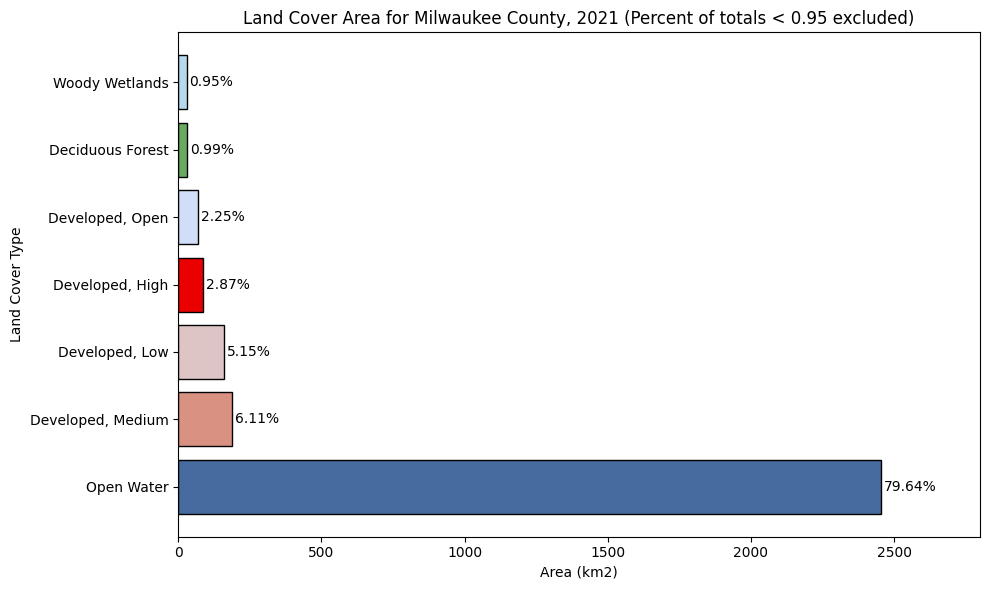

In [52]:
# 5.3

fig, ax = plt.subplots(figsize=(10, 6))

data = pd.DataFrame(results)
results = data[data['percent']>0.9]

colors = {
    'Cultivated Crops': '#ab6c28',
    'Pasture/Hay': '#dcd939',
    'Deciduous Forest': '#68ab5f',
    'Developed, Low': '#dec5c5',
    'Developed, Open': '#d1def8',
    'Open Water': '#466b9f',
    'Developed, Medium': '#d99282',
    'Woody Wetlands': '#b8d9eb',
    'Grassland': '#dfdfc2',
    'Developed, High': '#eb0000',
}

# this code matches the class to its corresponding color defined in colors. If no color is found, gray is shown
bar_colors = [colors.get(c, 'gray') for c in results['class']]

bars = ax.barh(results['class'], results['area_km2'], color=bar_colors, edgecolor='black')
percent = results['percent']
for bars, percent in zip (bars, percent):
    ax.text(bars.get_width() + 10 , bars.get_y() + bars.get_height()/2, f'{percent:.2f}%', va='center', fontsize=10)

ax.set_xlim(0, 2800)
ax.set_xlabel('Area (km2)')
ax.set_ylabel('Land Cover Type')
ax.set_title('Land Cover Area for Milwaukee County, 2021 (Percent of totals < 0.95 excluded)')
plt.tight_layout()
plt.show()


#### 5.4

a) What are the **two most dominant** land cover types in your study area? Does this match your expectations based on your knowledge of the region?

* The most dominant land type is open water, which was expected, as the boundaries for Milwaukee county extend to cover a large portion of Lake Michigan. The second most dominant is devloped (medium) land, which also does not surprise me, as Milwaukee county is among the most densely-populated areas of the state.


b) What percentage of your study area is **developed** (sum of all developed classes)? How does this compare to the percentage of **forest** (sum of all forest classes)?

* Using the data from the bar chart, approximately 16.4 percent of land cover in Milwaukee County is developed land. The sum of forest classes in comparison is miniscule, occupying only around 1% of the total land cover. This is a reflection of the urbanization of the area.


### Problem 6

In [53]:
veg_point = ee.Geometry.Point([-87.8808, 43.0794]) # Downer Woods Field Station on the UW Milwaukee Campus
modis = ee.ImageCollection('MODIS/061/MOD13Q1')

modis_2023 = (modis
              .filterDate('2023-01-01', '2023-12-31')
              .filterBounds(study_area)
              .select('NDVI')
)

def scale_modis(image):
    return image.multiply(0.0001).copyProperties(image, ['system:time_start'])

modis_2023 = modis_2023.map(scale_modis)

image_list = modis_2023.toList(modis_2023.size())
n_images = modis_2023.size().getInfo()

records = []

for i in range(n_images):
    image = ee.Image(image_list.get(i))

    # Get date
    date = image.date().format('YYYY-MM-dd').getInfo()

    # Extract NDVI value at point
    value = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=veg_point,
        scale=250
    ).get('NDVI').getInfo()

    if value is not None:
        records.append({
            'date': date,
            'name': 'Downer Woods',
            'NDVI': value
        })

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
df['doy'] = df['date'].dt.dayofyear

print(f"Extracted {len(df)} observations")
df.head()

Extracted 23 observations


,date,name,NDVI,doy
0,2023-01-01,Downer Woods,0.2847,1
1,2023-01-17,Downer Woods,0.0280,17
2,2023-02-02,Downer Woods,0.0378,33
3,2023-02-18,Downer Woods,0.0081,49
4,2023-03-06,Downer Woods,0.2330,65


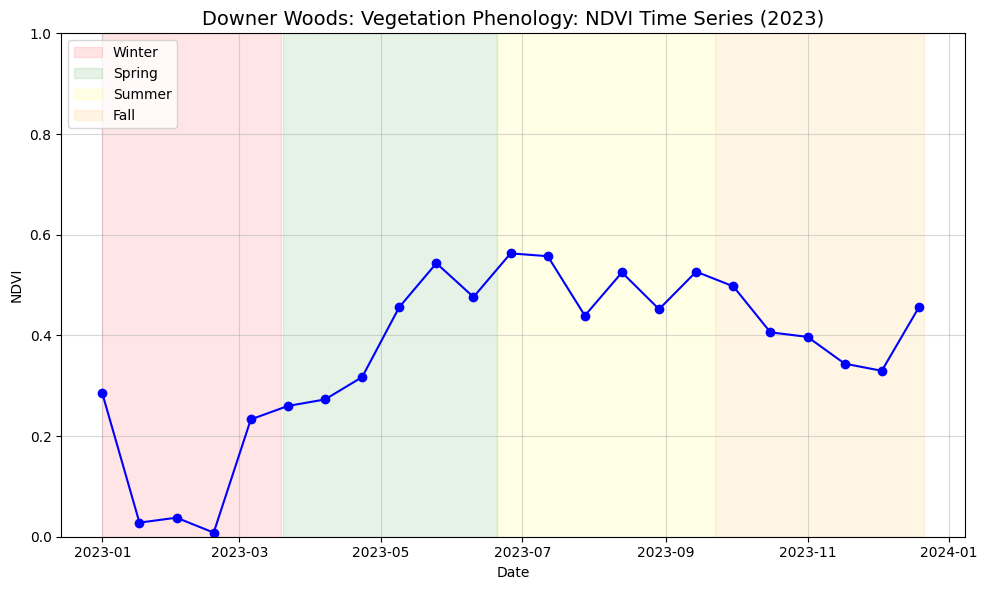

In [54]:
# 6.3

fig, ax = plt.subplots(figsize=(10, 6))
df = df.sort_values('date')

ax.plot(df['date'], df['NDVI'], marker='o', linestyle='-', color='b')
ax.set_xlabel('Date')
ax.set_ylabel('NDVI')
ax.set_title('Downer Woods: Vegetation Phenology: NDVI Time Series (2023)', fontsize=14)
ax.grid(True, alpha=0.5)
ax.set_ylim(0,1)

ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-03-19'),
           alpha=0.1, color='red', label='Winter')
ax.axvspan(pd.Timestamp('2023-03-20'), pd.Timestamp('2023-06-20'),
           alpha=0.1, color='green', label='Spring')
ax.axvspan(pd.Timestamp('2023-06-20'), pd.Timestamp('2023-09-22'),
           alpha=0.1, color='yellow', label='Summer')
ax.axvspan(pd.Timestamp('2023-09-22'), pd.Timestamp('2023-12-21'),
           alpha=0.1, color='orange', label='Fall')

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
# 6.4

def extract_phenology_metrics(site):
  site = site.sort_values('doy').copy()
  site['NDVI_smooth'] = site['NDVI'].rolling(window=3, center=True,min_periods=1).mean()

  metrics = {}
  peak_idx = site['NDVI_smooth'].idxmax()
  metrics['peak_ndvi'] = site.loc[peak_idx, 'NDVI_smooth']
  metrics['peak_date'] = site.loc[peak_idx, 'date']
  metrics['peak_doy'] = site.loc[peak_idx, 'doy']

  min_idx = site['NDVI_smooth'].idxmin()
  metrics['min_ndvi'] = site.loc[min_idx, 'NDVI_smooth']

  metrics['amplitude'] = metrics['peak_ndvi'] - metrics['min_ndvi']

  threshold = metrics['min_ndvi'] + 0.5 * metrics['amplitude']

  spring = site[(site['doy'] >= 60) & (site['doy'] <= 180)]
  above_threshold = spring[spring['NDVI_smooth'] >= threshold]
  if len(above_threshold) > 0:
        metrics['sos_date'] = above_threshold.iloc[0]['date']
        metrics['sos_doy'] = above_threshold.iloc[0]['doy']

  fall = site[(site['doy'] >= 220) & (site['doy'] <= 330)]
  below_threshold = fall[fall['NDVI_smooth'] <= threshold]
  if len(below_threshold) > 0:
        metrics['eos_date'] = below_threshold.iloc[0]['date']
        metrics['eos_doy'] = below_threshold.iloc[0]['doy']

  if 'sos_doy' in metrics and 'eos_doy' in metrics:
        metrics['growing_season_length'] = metrics['eos_doy'] - metrics['sos_doy']

  return metrics

In [56]:
print("Phenological Metrics (2023)")
print("=" * 65)

all_metrics = {}

for name in df['name'].unique():
    site = df[df['name'] == name].copy()
    metrics = extract_phenology_metrics(site)
    all_metrics[name] = metrics

    print(f"\n{name}:")
    print(f"  Peak NDVI: {metrics['peak_ndvi']:.3f}")
    print(f"  Peak Date: {metrics['peak_date'].strftime('%B %d')} (DOY {metrics['peak_doy']})")
    print(f"  Min NDVI: {metrics['min_ndvi']:.3f}")
    print(f"  Amplitude: {metrics['amplitude']:.3f}")

    if 'sos_date' in metrics:
        print(f"  Start of Season: {metrics['sos_date'].strftime('%B %d')} (DOY {metrics['sos_doy']})")
    if 'eos_date' in metrics:
        print(f"  End of Season: {metrics['eos_date'].strftime('%B %d')} (DOY {metrics['eos_doy']})")
    if 'growing_season_length' in metrics:
        print(f"  Growing Season: {metrics['growing_season_length']} days")

Phenological Metrics (2023)

Downer Woods:
  Peak NDVI: 0.532
  Peak Date: June 26 (DOY 177)
  Min NDVI: 0.025
  Amplitude: 0.508
  Start of Season: April 07 (DOY 97)


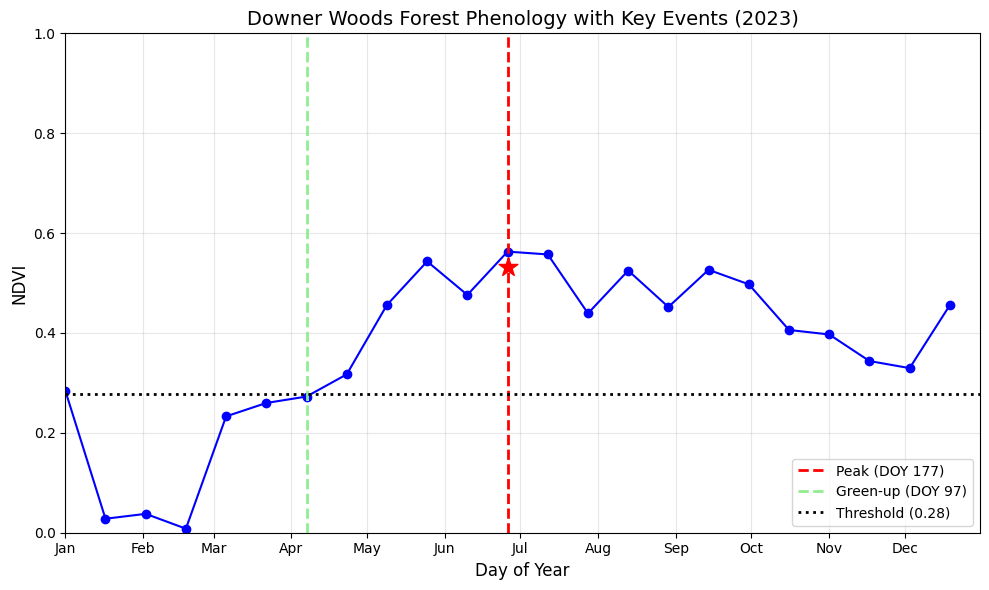

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['doy'], df['NDVI'], marker='o', linestyle='-', color='b')
m = all_metrics['Downer Woods']

ax.axvline(m['peak_doy'], color='red', linestyle='--', linewidth=2, label=f"Peak (DOY {m['peak_doy']})")
ax.scatter([m['peak_doy']], [m['peak_ndvi']], s=200, c='red', zorder=5, marker='*')

if 'sos_doy' in m:
    ax.axvline(m['sos_doy'], color='lightgreen', linestyle='--', linewidth=2, label=f"Green-up (DOY {m['sos_doy']})")

if 'eos_doy' in m:
    ax.axvline(m['eos_doy'], color='orange', linestyle='--', linewidth=2, label=f"Senescence (DOY {m['eos_doy']})")

threshold = m['min_ndvi'] + 0.5 * m['amplitude']
ax.axhline(threshold, color='black', linestyle=':', linewidth=2, label=f"Threshold ({threshold:.2f})")

ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Downer Woods Forest Phenology with Key Events (2023)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 365)
ax.set_ylim(0, 1)

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.show()

#### 6.5


a) When did peak greenness occur at your location? Is this timing consistent with what you would expect for this vegetation type and location?

* Peak greeness occured on day 177 with an NDVI of 0.532. This corresponds to the end of spring season. This result is consistent for what I would expect for the type of vegetation (deciduous forest), as chloryphyll content is highest around this time of year. In Milwaukee, this is also when temperatures are favorable for vegetation, and there is an abundance of sunlight.


b) How long was the growing season? How might this compare to locations further north or south?

* Based on the calculated phenological metrics, a growing season length was unable to be calculated, due to the threshold level. However, in northern areas, such as northern Wisconsin it would be expected that the growing season is shorter, based on a northern latitude, resulting in less sun-intensity and more intense cool seasons. On the contrary, this is expected to be the opposite in southern regions.
